In [75]:
import math
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [76]:
class Neuron:
    def __init__(self, n_inputs):
        self.n_inputs = n_inputs
        self.weights  = [0.0] * n_inputs
        self.bias     = 0.0
        self.z        = 0.0
        self.output   = 0.0

    @staticmethod
    def sigmoid(z):
        if z >= 0:
            return 1.0 / (1.0 + math.exp(-z))
        e = math.exp(z)
        return e / (1.0 + e)

    def forward(self, inputs):
        self.z      = sum(self.weights[j] * inputs[j] for j in range(self.n_inputs)) + self.bias
        self.output = self.sigmoid(self.z)
        return self.output

    def __repr__(self):
        w_str = ', '.join(f'{w:+.4f}' for w in self.weights)
        return f'Neuron(bias={self.bias:+.4f}, weights=[{w_str}])'

In [77]:
class Layer:
    def __init__(self, n_neurons, n_inputs):
        self.n_neurons = n_neurons
        self.n_inputs  = n_inputs
        self.neurons   = [Neuron(n_inputs) for _ in range(n_neurons)]

    def forward(self, inputs):
        return [neuron.forward(inputs) for neuron in self.neurons]

    def __repr__(self):
        return f'Layer({self.n_neurons} neurons, {self.n_inputs} inputs each)'

In [78]:
class NeuralNetwork:
    def __init__(self):
        self.layers      = []
        self.layer_sizes = []

    @classmethod
    def from_config_file(cls, config_file):
        nn = cls()
        with open(config_file, 'r') as f:
            lines = [l.strip() for l in f if l.strip() and not l.startswith('#')]
        n_total          = int(lines[0])
        nn.layer_sizes   = [int(lines[i + 1]) for i in range(n_total)]
        for l in range(1, n_total):
            nn.layers.append(Layer(nn.layer_sizes[l], nn.layer_sizes[l - 1]))
        return nn

    def init_random(self, seed=None):
        if seed is not None:
            random.seed(seed)
        for layer in self.layers:
            for neuron in layer.neurons:
                neuron.bias    = random.random()
                neuron.weights = [random.random() for _ in neuron.weights]

    def init_from_file(self, weight_file):
        with open(weight_file, 'r') as f:
            lines = [l.strip() for l in f if l.strip() and not l.startswith('#')]
        idx = 0
        for layer in self.layers:
            for neuron in layer.neurons:
                vals           = list(map(float, lines[idx].split()))
                neuron.bias    = vals[0]
                neuron.weights = vals[1:]
                idx += 1

    def save_weights(self, weight_file):
        with open(weight_file, 'w') as f:
            for l, layer in enumerate(self.layers):
                f.write(f'# Layer {l + 1}\n')
                for neuron in layer.neurons:
                    row = [neuron.bias] + neuron.weights
                    f.write('  '.join(f'{v:.6f}' for v in row) + '\n')

    def feedforward(self, inputs):
        current = list(inputs)
        for layer in self.layers:
            current = layer.forward(current)
        return current

    def summary(self):
        arch = ' -> '.join(str(s) for s in self.layer_sizes)
        print(f'NeuralNetwork  architecture: [{arch}]')
        print(f'Computational layers: {len(self.layers)}')
        for l, layer in enumerate(self.layers):
            print(f'  Layer {l + 1}: {layer}')
            for n, neuron in enumerate(layer.neurons):
                print(f'    Neuron {n + 1}: {neuron}')

In [79]:
with open('xor_arch.txt', 'w') as f:
    f.write('3\n2\n2\n1\n')

with open('xor_weights.txt', 'w') as f:
    f.write('# Layer 1 (hidden): NOT_AND, OR\n')
    f.write(' 1.5 -1.0 -1.0\n')
    f.write('-0.5  1.0  1.0\n')
    f.write('# Layer 2 (output): AND\n')
    f.write('-1.5  1.0  1.0\n')

with open('general_arch.txt', 'w') as f:
    f.write('4\n2\n3\n3\n1\n')

print('Config files created.')
print()
print('--- xor_arch.txt ---')
with open('xor_arch.txt') as f:
    print(f.read())
print('--- xor_weights.txt ---')
with open('xor_weights.txt') as f:
    print(f.read())

Config files created.

--- xor_arch.txt ---
3
2
2
1

--- xor_weights.txt ---
# Layer 1 (hidden): NOT_AND, OR
 1.5 -1.0 -1.0
-0.5  1.0  1.0
# Layer 2 (output): AND
-1.5  1.0  1.0



In [80]:
nn_general = NeuralNetwork.from_config_file('general_arch.txt')
nn_general.init_random(seed=0)
print('=== General Network [2->3->3->1] – Random Initialisation ===')
nn_general.summary()
print()
demo_out = nn_general.feedforward([0.5, 0.8])
print(f'feedforward([0.5, 0.8]) = {demo_out[0]:.6f}')

=== General Network [2->3->3->1] – Random Initialisation ===
NeuralNetwork  architecture: [2 -> 3 -> 3 -> 1]
Computational layers: 3
  Layer 1: Layer(3 neurons, 2 inputs each)
    Neuron 1: Neuron(bias=+0.8444, weights=[+0.7580, +0.4206])
    Neuron 2: Neuron(bias=+0.2589, weights=[+0.5113, +0.4049])
    Neuron 3: Neuron(bias=+0.7838, weights=[+0.3033, +0.4766])
  Layer 2: Layer(3 neurons, 3 inputs each)
    Neuron 1: Neuron(bias=+0.5834, weights=[+0.9081, +0.5047, +0.2818])
    Neuron 2: Neuron(bias=+0.7558, weights=[+0.6184, +0.2505, +0.9097])
    Neuron 3: Neuron(bias=+0.9828, weights=[+0.8102, +0.9022, +0.3101])
  Layer 3: Layer(1 neurons, 3 inputs each)
    Neuron 1: Neuron(bias=+0.7298, weights=[+0.8988, +0.6840, +0.4721])

feedforward([0.5, 0.8]) = 0.928441


In [81]:
nn_xor = NeuralNetwork.from_config_file('xor_arch.txt')
nn_xor.init_from_file('xor_weights.txt')
print('=== XOR Network [2->2->1] – Weights from Slides ===')
nn_xor.summary()

nn_xor.save_weights('xor_weights_saved.txt')
print('\nWeights saved to xor_weights_saved.txt')
with open('xor_weights_saved.txt') as f:
    print(f.read())

=== XOR Network [2->2->1] – Weights from Slides ===
NeuralNetwork  architecture: [2 -> 2 -> 1]
Computational layers: 2
  Layer 1: Layer(2 neurons, 2 inputs each)
    Neuron 1: Neuron(bias=+1.5000, weights=[-1.0000, -1.0000])
    Neuron 2: Neuron(bias=-0.5000, weights=[+1.0000, +1.0000])
  Layer 2: Layer(1 neurons, 2 inputs each)
    Neuron 1: Neuron(bias=-1.5000, weights=[+1.0000, +1.0000])

Weights saved to xor_weights_saved.txt
# Layer 1
1.500000  -1.000000  -1.000000
-0.500000  1.000000  1.000000
# Layer 2
-1.500000  1.000000  1.000000



In [82]:
xor_inputs   = [(0, 0), (0, 1), (1, 0), (1, 1)]
xor_expected = [      0,      1,      1,      0]

print(f'{"x1":>3} {"x2":>3}  {"Expected":>9}  {"Output":>8}  {"Pred":>5}  {"OK?":>4}')
print('-' * 45)

results, predictions, correct_flags = [], [], []

for (x1, x2), expected in zip(xor_inputs, xor_expected):
    out  = nn_xor.feedforward([x1, x2])[0]
    pred = 1 if out >= 0.5 else 0
    ok   = (pred == expected)
    results.append(out)
    predictions.append(pred)
    correct_flags.append(ok)
    mark = 'OK' if ok else 'FAIL'
    print(f'{x1:>3} {x2:>3}  {expected:>9}  {out:>8.4f}  {pred:>5}  {mark:>4}')

accuracy = sum(correct_flags) / len(correct_flags) * 100
print(f'\nAccuracy: {sum(correct_flags)}/{len(correct_flags)} = {accuracy:.0f}%')

 x1  x2   Expected    Output   Pred   OK?
---------------------------------------------
  0   0          0    0.4244      0    OK
  0   1          1    0.4366      0  FAIL
  1   0          1    0.4366      0  FAIL
  1   1          0    0.4244      0    OK

Accuracy: 2/4 = 50%


In [83]:

hdr = f'{"Input":>8}  {"z_h1":>7}  {"a_h1":>7}  {"z_h2":>7}  {"a_h2":>7}  {"z_out":>8}  {"a_out":>7}  Pred  Exp'

print(hdr)
print('-' * len(hdr))

for (x1, x2), expected in zip(xor_inputs, xor_expected):

    nn_xor.feedforward([x1, x2])

    h1_z = nn_xor.layers[0].neurons[0].z
    h1_a = nn_xor.layers[0].neurons[0].output

    h2_z = nn_xor.layers[0].neurons[1].z
    h2_a = nn_xor.layers[0].neurons[1].output

    out_z = nn_xor.layers[1].neurons[0].z
    out_a = nn_xor.layers[1].neurons[0].output

    pred = 1 if out_a >= 0.5 else 0

    print(
        f'({x1},{x2})->{expected}  '
        f'{h1_z:>+7.4f}  {h1_a:>7.4f}  '
        f'{h2_z:>+7.4f}  {h2_a:>7.4f}  '
        f'{out_z:>+8.4f}  {out_a:>7.4f}  '
        f'{pred:>4}  {expected:>3}'
    )

   Input     z_h1     a_h1     z_h2     a_h2     z_out    a_out  Pred  Exp
--------------------------------------------------------------------------
(0,0)->0  +1.5000   0.8176  -0.5000   0.3775   -0.3049   0.4244     0    0
(0,1)->1  +0.5000   0.6225  +0.5000   0.6225   -0.2551   0.4366     0    1
(1,0)->1  +0.5000   0.6225  +0.5000   0.6225   -0.2551   0.4366     0    1
(1,1)->0  -0.5000   0.3775  +1.5000   0.8176   -0.3049   0.4244     0    0


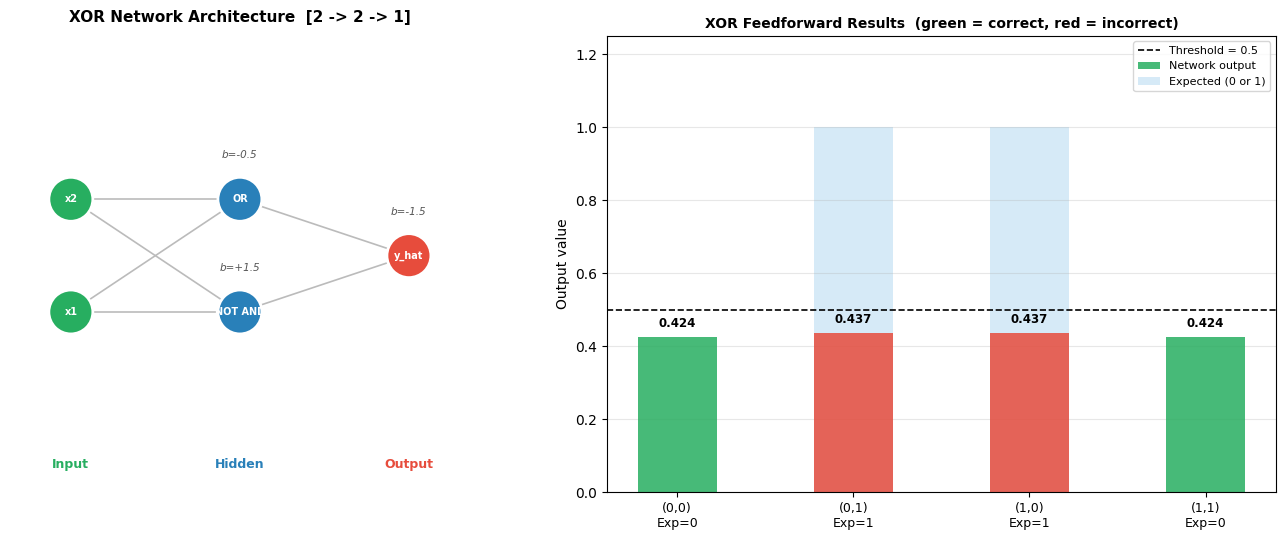

Saved: xor_results.png


In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
layer_sizes = [2, 2, 1]
n_layers    = len(layer_sizes)
positions   = []
for l, size in enumerate(layer_sizes):
    x   = l / (n_layers - 1)
    col = [(x, (n + 1) / (size + 1)) for n in range(size)]
    positions.append(col)

for l in range(1, n_layers):
    for (x0, y0) in positions[l - 1]:
        for (x1, y1) in positions[l]:
            ax.plot([x0, x1], [y0, y1], color='#BBBBBB', linewidth=1.2, zorder=1)

colors      = ['#27AE60', '#2980B9', '#E74C3C']
layer_names = ['Input', 'Hidden', 'Output']
node_labels = [['x1', 'x2'], ['NOT AND', 'OR'], ['y_hat']]
node_r      = 0.065

for l, (col, color) in enumerate(zip(positions, colors)):
    for n, (x, y) in enumerate(col):
        c = plt.Circle((x, y), node_r, color=color, zorder=2, ec='white', lw=2)
        ax.add_patch(c)
        ax.text(x, y, node_labels[l][n], ha='center', va='center',
                fontsize=7, color='white', fontweight='bold', zorder=3)
    ax.text(col[0][0], -0.10, layer_names[l], ha='center', va='top',
            fontsize=9, fontweight='bold', color=color)

bias_data = [
    (positions[1][0], 'b=+1.5'),
    (positions[1][1], 'b=-0.5'),
    (positions[2][0], 'b=-1.5'),
]
for (x, y), label in bias_data:
    ax.text(x, y + node_r + 0.05, label, ha='center', va='bottom',
            fontsize=7.5, color='#555', style='italic')

ax.set_xlim(-0.18, 1.18)
ax.set_ylim(-0.20, 1.15)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('XOR Network Architecture  [2 -> 2 -> 1]', fontsize=11, fontweight='bold', pad=10)

ax2     = axes[1]
x_pos   = list(range(4))
x_lbls  = ['(0,0)\nExp=0', '(0,1)\nExp=1', '(1,0)\nExp=1', '(1,1)\nExp=0']
bar_clr = ['#27AE60' if correct_flags[i] else '#E74C3C' for i in range(4)]

bars = ax2.bar(x_pos, results, color=bar_clr, alpha=0.85, width=0.45,
               label='Network output', zorder=2)
ax2.bar(x_pos, xor_expected, color='#3498DB', alpha=0.20, width=0.45,
        label='Expected (0 or 1)', zorder=1)
ax2.axhline(0.5, color='black', linestyle='--', linewidth=1.2, label='Threshold = 0.5')

for b, v in zip(bars, results):
    ax2.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.3f}',
             ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_lbls, fontsize=9)
ax2.set_ylabel('Output value')
ax2.set_ylim(0, 1.25)
ax2.set_title('XOR Feedforward Results  (green = correct, red = incorrect)',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y', zorder=0)

plt.tight_layout()
plt.savefig('xor_results.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: xor_results.png')

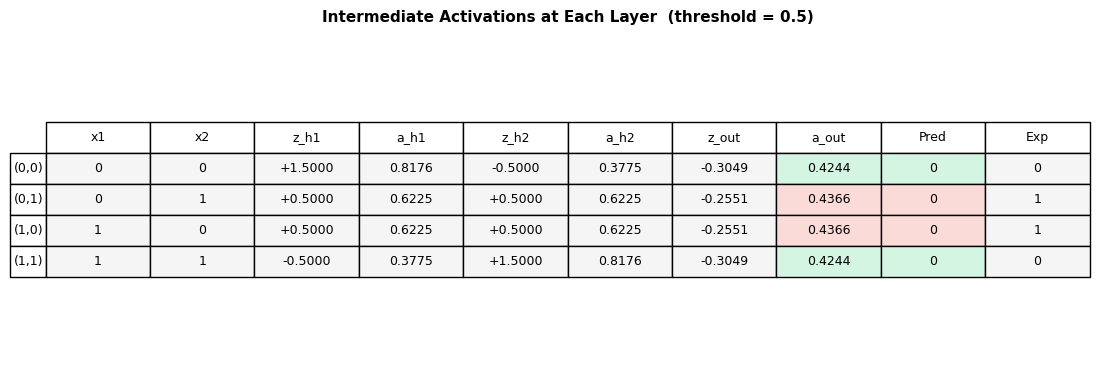

Saved: xor_intermediate.png


In [85]:
fig, ax = plt.subplots(figsize=(11, 3.8))

col_labels = ['x1', 'x2', 'z_h1', 'a_h1', 'z_h2', 'a_h2', 'z_out', 'a_out', 'Pred', 'Exp']

table_data  = []
row_labels  = []
cell_colors = []

for (x1, x2), expected in zip(xor_inputs, xor_expected):
    nn_xor.feedforward([x1, x2])
    h1z = nn_xor.layers[0].neurons[0].z
    h1a = nn_xor.layers[0].neurons[0].output
    h2z = nn_xor.layers[0].neurons[1].z
    h2a = nn_xor.layers[0].neurons[1].output
    oz  = nn_xor.layers[1].neurons[0].z
    oa  = nn_xor.layers[1].neurons[0].output
    pred = 1 if oa >= 0.5 else 0
    ok   = (pred == expected)

    row_labels.append(f'({x1},{x2})')
    table_data.append([x1, x2, f'{h1z:+.4f}', f'{h1a:.4f}',
                       f'{h2z:+.4f}', f'{h2a:.4f}',
                       f'{oz:+.4f}', f'{oa:.4f}', pred, expected])
    c_row = ['#F5F5F5'] * len(col_labels)
    c_row[7] = '#D5F5E3' if ok else '#FADBD8'
    c_row[8] = '#D5F5E3' if ok else '#FADBD8'
    cell_colors.append(c_row)

tbl = ax.table(
    cellText    = table_data,
    rowLabels   = row_labels,
    colLabels   = col_labels,
    cellColours = cell_colors,
    loc         = 'center',
    cellLoc     = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.7)

ax.axis('off')
ax.set_title('Intermediate Activations at Each Layer  (threshold = 0.5)',
             fontsize=11, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('xor_intermediate.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: xor_intermediate.png')